## Task 1: Develop predictive regression models using Linear Regression techniques for continuous-valued data analysis
*Suggested Dataset: Boston Housing Dataset (Fetched via public repository URL)*


In [1]:
import pandas as pd

In [2]:
from sklearn.model_selection import train_test_split

In [3]:
import warnings

In [4]:
warnings.filterwarnings("ignore")

In [5]:
boston_url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

In [6]:
boston_df = pd.read_csv(boston_url)

In [7]:
features = [col for col in boston_df.columns if col != 'medv']

In [8]:
X = boston_df[features]

In [9]:
y = boston_df['medv']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [11]:
print("Dataset Dimensions (rows, cols):", boston_df.shape)

Dataset Dimensions (rows, cols): (506, 14)


In [12]:
print("Missing values per column:\n", boston_df.isnull().sum())

Missing values per column:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


In [13]:
print("\nFirst 3 rows of target data:")
print(y_train.head(3))


First 3 rows of target data:
477    12.0
15     19.9
332    19.4
Name: medv, dtype: float64


In [14]:
from sklearn.preprocessing import StandardScaler

In [15]:
scaler = StandardScaler()

In [16]:
X_train_scaled = scaler.fit_transform(X_train)

In [17]:
X_test_scaled = scaler.transform(X_test)

In [18]:
print("Standardized training features mean (approx 0):", round(X_train_scaled.mean(), 4))
print("Standardized training features std dev (approx 1):", round(X_train_scaled.std(), 4))

Standardized training features mean (approx 0): -0.0
Standardized training features std dev (approx 1): 1.0


In [19]:
from sklearn.linear_model import LinearRegression

In [20]:
lr_model = LinearRegression()

In [21]:
lr_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](13,)","[-0.11, 0.03, 0.04,...,-0.92, 0.01,-0.51]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](13,)","['crim','zn','indus',...,'ptratio','b','lstat']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,30.25
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(13)


In [22]:
y_pred = lr_model.predict(X_test)

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [24]:
import numpy as np

In [25]:
y_pred = lr_model.predict(X_test)

In [26]:
mae = mean_absolute_error(y_test, y_pred)

In [27]:
mse = mean_squared_error(y_test, y_pred)

In [28]:
rmse = np.sqrt(mse)

In [29]:
r2 = r2_score(y_test, y_pred)

In [31]:
print("Linear Regression Performance Metrics")
print("-------------------------------------")
print(f"Mean Absolute Error (MAE)      : {mae:.4f}")
print(f"Mean Squared Error (MSE)       : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score                       : {r2:.4f}")

Linear Regression Performance Metrics
-------------------------------------
Mean Absolute Error (MAE)      : 3.1891
Mean Squared Error (MSE)       : 24.2911
Root Mean Squared Error (RMSE) : 4.9286
R² Score                       : 0.6688


In [32]:
import matplotlib.pyplot as plt

In [33]:
lr_predictions = lr_model.predict(X_test)

In [34]:
plt.figure(figsize=(7,5))

<Figure size 700x500 with 0 Axes>

<Figure size 700x500 with 0 Axes>

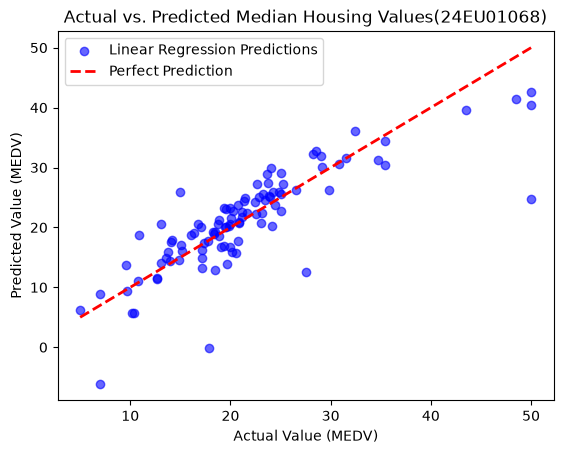

In [36]:
plt.scatter(y_test, lr_predictions,
            color='blue',
            alpha=0.6,
            label='Linear Regression Predictions')

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--',
         lw=2,
         label='Perfect Prediction')

plt.title("Actual vs. Predicted Median Housing Values(24EU01068)")
plt.xlabel("Actual Value (MEDV)")
plt.ylabel("Predicted Value (MEDV)")
plt.legend()

plt.show()